Cell 1 — Import libraries

In [3]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_all_data
from src.validation import validate_all_data
from src.data_cleaner import clean_data, save_cleaned_data
from src.insurance_analysis import calculate_kpis
sns.set_theme(style="whitegrid")

Cell 2 — Load the raw datasets

In [6]:
data = load_all_data(data_dir=PROJECT_ROOT / "data" / "raw")

for name, dataframe in data.items():
    print(f"{name}: {dataframe.shape}")
    display(dataframe.head())

2026-10-09 10:24:26,947 - INFO - Loaded customers.csv: 20000 rows
2026-10-09 10:24:27,001 - INFO - Loaded vehicles.csv: 25000 rows
2026-10-09 10:24:27,066 - INFO - Loaded policies.csv: 25000 rows
2026-10-09 10:24:27,100 - INFO - Loaded claims.csv: 10000 rows
2026-10-09 10:24:27,121 - INFO - Loaded payments.csv: 7000 rows
2026-10-09 10:24:27,121 - INFO - All five CSV files loaded successfully


customers: (20000, 8)


,customer_id,customer_name,gender,date_of_birth,age,city,state,occupation
0,CUST_000001,Aryan Maharaj,Male,1980-09-27,46,Bengaluru,Karnataka,Business Owner
1,CUST_000002,Udant Dewan,Male,1990-08-03,36,Chennai,Tamil Nadu,Sales Executive
2,CUST_000003,Gagan Sami,Male,1969-06-01,57,Karimnagar,Telangana,Software Engineer
3,CUST_000004,Ayushman Chander,Female,1965-10-21,60,Warangal,Telangana,Teacher
4,CUST_000005,Viraj Tiwari,Male,1997-11-10,28,Jaipur,Rajasthan,Software Engineer


vehicles: (25000, 8)


,vehicle_id,customer_id,vehicle_type,vehicle_make,vehicle_model,vehicle_year,fuel_type,vehicle_value
0,VEH_000001,CUST_000216,Car,Tata,Tiago,2023,Petrol,602727.06
1,VEH_000002,CUST_011180,Car,Tata,Punch,2023,CNG,860471.13
2,VEH_000003,CUST_012391,Car,Hyundai,i20,2017,Diesel,751541.48
3,VEH_000004,CUST_005106,Car,Maruti Suzuki,Dzire,2017,Diesel,611920.86
4,VEH_000005,CUST_008384,Car,Maruti Suzuki,Baleno,2021,Diesel,868381.67


...

,policy_id,customer_id,vehicle_id,policy_start_date,policy_end_date,policy_type,premium_amount,coverage_amount,policy_status,payment_frequency
0,POL_000001,CUST_000216,VEH_000001,2026-04-10,2027-04-09,Comprehensive,18799.02,572309.02,Active,Annual
1,POL_000002,CUST_011180,VEH_000002,2024-09-30,2025-09-29,Comprehensive,24413.33,812763.96,Renewed,Semi-Annual
2,POL_000003,CUST_012391,VEH_000003,2024-01-30,2025-01-29,Comprehensive,27496.06,738543.68,Expired,Annual
3,POL_000004,CUST_005106,VEH_000004,2023-10-25,2024-10-24,Comprehensive,16152.26,588084.92,Renewed,Annual
4,POL_000005,CUST_008384,VEH_000005,2024-03-27,2025-03-26,Third Party,7510.84,961163.46,Renewed,Annual


claims: (10000, 12)


,claim_id,policy_id,customer_id,claim_date,accident_date,claim_type,accident_location,claim_amount,claim_status,approval_date,settlement_date,damage_severity
0,CLM_000001,POL_011277,CUST_018960,2025-01-13,2025-01-07,Third Party Damage,City Road,256572.56,Settled,2025-01-24,2025-01-31,Low
1,CLM_000002,POL_020774,CUST_003532,2026-05-25,2026-05-12,Accident,Parking Area,141080.87,Pending,NaN,NaN,Low
2,CLM_000003,POL_023289,CUST_009274,2024-04-19,2024-04-17,Third Party Damage,"Phusro, West Bengal",95522.84,Rejected,NaN,NaN,Low
3,CLM_000004,POL_002900,CUST_001472,2025-04-14,2025-04-12,Accident,Parking Area,297129.35,Approved,2025-04-18,NaN,Medium
4,CLM_000005,POL_016133,CUST_007482,2026-09-07,2026-08-28,Fire,Parking Area,493369.84,Approved,2026-09-18,NaN,High


payments: (7000, 7)


,payment_id,claim_id,policy_id,payment_date,payment_amount,payment_status,payment_method
0,PAY_000001,CLM_004650,POL_002355,2025-12-02,59275.42,Completed,Bank Transfer
1,PAY_000002,CLM_002291,POL_021490,2025-09-08,91119.70,Completed,UPI
2,PAY_000003,CLM_003111,POL_024892,2025-06-19,331851.20,Completed,Cheque
3,PAY_000004,CLM_004617,POL_023457,2025-07-06,102610.77,Completed,Bank Transfer
4,PAY_000005,CLM_008185,POL_023897,2026-07-20,236240.50,Completed,Bank Transfer


Cell 3 — Check data quality

In [7]:
validation_errors = validate_all_data(data)

if validation_errors:
    print("Data validation issues:")
    for error in validation_errors:
        print("-", error)
else:
    print("All data validation checks passed.")

All data validation checks passed.


Cell 4 — Explore customers

In [8]:
customers = data["customers"]

print("Total customer records:", len(customers))
print("\nMissing values:")
display(customers.isnull().sum().to_frame("missing_count"))

if "gender" in customers.columns:
    display(customers["gender"].value_counts(dropna=False))

if "city" in customers.columns:
    display(customers["city"].value_counts().head(10))

Total customer records: 20000

Missing values:


,missing_count
customer_id,0
customer_name,0
gender,0
date_of_birth,0
age,0
city,0
state,0
occupation,0


gender
Male      12451
Female     7549
Name: count, dtype: int64

city
Kota                  633
Nashik                632
Bhopal                626
Kochi                 625
Thiruvananthapuram    618
Kolkata               611
Ahmedabad             609
Jaipur                603
Karimnagar            602
Noida                 602
Name: count, dtype: int64

Cell 5 — Explore policies

In [9]:
policies = data["policies"]

print("Total policies:", len(policies))

if "policy_status" in policies.columns:
    display(policies["policy_status"].value_counts(dropna=False))

if "premium_amount" in policies.columns:
    policies["premium_amount"] = pd.to_numeric(
        policies["premium_amount"], errors="coerce"
    )
    display(policies["premium_amount"].describe())

Total policies: 25000


policy_status
Expired      10464
Active        7551
Renewed       6665
Cancelled      320
Name: count, dtype: int64

count     25000.000000
mean      31822.750868
std       18099.401252
min        3827.980000
25%       18579.620000
50%       28917.665000
75%       42017.002500
max      100000.000000
Name: premium_amount, dtype: float64

Cell 6 — Explore claims

In [10]:
claims = data["claims"]

print("Total claims:", len(claims))

if "claim_status" in claims.columns:
    display(claims["claim_status"].value_counts(dropna=False))

if "claim_type" in claims.columns:
    display(claims["claim_type"].value_counts(dropna=False))

if "claim_amount" in claims.columns:
    claims["claim_amount"] = pd.to_numeric(
        claims["claim_amount"], errors="coerce"
    )
    display(claims["claim_amount"].describe())

Total claims: 10000


claim_status
Approved    3790
Settled     3259
Pending     1791
Rejected    1160
Name: count, dtype: int64

claim_type
Accident              4838
Third Party Damage    2022
Theft                 1585
Natural Disaster       796
Fire                   759
Name: count, dtype: int64

count    1.000000e+04
mean     2.885436e+05
std      2.630481e+05
min      1.228147e+04
25%      1.017115e+05
50%      2.050401e+05
75%      3.918843e+05
max      2.645660e+06
Name: claim_amount, dtype: float64

Cell 7 — Visualize claim status

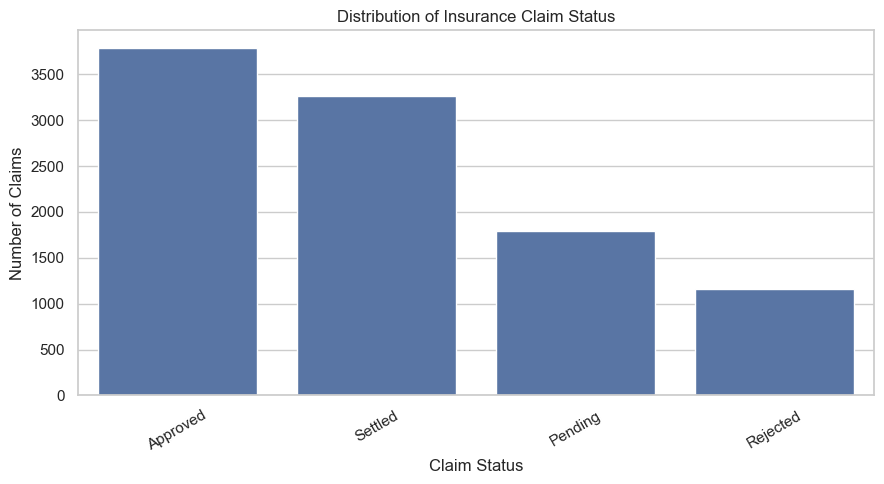

In [11]:
if not claims.empty and "claim_status" in claims.columns:
    plt.figure(figsize=(9, 5))
    sns.countplot(
        data=claims,
        x="claim_status",
        order=claims["claim_status"].value_counts().index,
    )
    plt.title("Distribution of Insurance Claim Status")
    plt.xlabel("Claim Status")
    plt.ylabel("Number of Claims")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Claim status data is unavailable for visualization.")

Cell 8 — Calculate KPIs

In [12]:
kpis = calculate_kpis(data)

print("Insurance Analytics KPIs")
print("-" * 35)

for name, value in kpis.items():
    print(f"{name}: {value}")

Insurance Analytics KPIs
-----------------------------------
total_customers: 20000
total_policies: 25000
active_policies: 7551
expired_policies: 10464
cancelled_policies: 320
renewed_policies: 6665
total_premium: 795568771.71
average_premium: 31822.750868400002
average_coverage: 1127529.3953935998
total_claims: 10000
total_claim_amount: 2885436440.6500006
average_claim_amount: 288543.64406500006
claim_approval_rate: 37.9
claim_rejection_rate: 11.600000000000001
average_processing_days: 8.308270676691729
average_settlement_days: 23.925744093280148
total_payment_amount: 1766889637.12
average_payment_amount: 252412.80530285713
claim_to_premium_ratio: 3.6268849950558355
claim_to_coverage_ratio: 0.1023631473356931
paid_claim_ratio: 0.6123474467252427


Cell 9 — Clean the data and save cleaned datasets

In [13]:
cleaned_data = clean_data(data)

cleaned_output = PROJECT_ROOT / "data" / "cleaned"
save_cleaned_data(cleaned_data, output_dir=cleaned_output)

print("Cleaned datasets saved to:", cleaned_output)

for name, dataframe in cleaned_data.items():
    print(f"{name}: {dataframe.shape}")

2026-10-09 10:27:51,539 - INFO - Data cleaning completed
2026-10-09 10:27:51,607 - INFO - Saved cleaned file: c:\Users\91939\Desktop\data science projects\assessment\motor\data\cleaned\customers_cleaned.csv
2026-10-09 10:27:51,692 - INFO - Saved cleaned file: c:\Users\91939\Desktop\data science projects\assessment\motor\data\cleaned\vehicles_cleaned.csv
2026-10-09 10:27:51,811 - INFO - Saved cleaned file: c:\Users\91939\Desktop\data science projects\assessment\motor\data\cleaned\policies_cleaned.csv
2026-10-09 10:27:51,894 - INFO - Saved cleaned file: c:\Users\91939\Desktop\data science projects\assessment\motor\data\cleaned\claims_cleaned.csv
2026-10-09 10:27:51,924 - INFO - Saved cleaned file: c:\Users\91939\Desktop\data science projects\assessment\motor\data\cleaned\payments_cleaned.csv


Cleaned datasets saved to: c:\Users\91939\Desktop\data science projects\assessment\motor\data\cleaned
customers: (20000, 9)
vehicles: (25000, 9)
policies: (25000, 12)
claims: (10000, 16)
payments: (7000, 8)
